# Equity Risk Modelling with Regime-Aware PCA

This notebook develops and evaluates a **regime-aware equity-risk modelling workflow** for a basket of large-cap US technology stocks.  
The objective is not to maximise backtest returns, but to improve the **out-of-sample quality of covariance / risk forecasts** in an interpretable and defensible way.

## Research question
Can a regime-aware challenger improve on a static low-rank PCA covariance model when regimes are inferred from an implied-volatility proxy?

## Modelling ladder
1. **Global / static PCA linear factor model baseline**
2. **Piecewise percentile PCA baseline** using an IV-driven state variable
3. **Two-state Gaussian HMM challenger** with filtered calm/stress probabilities and covariance mixing

## What to expect from the results
There are **two different layers of evidence** in this notebook, and they should not be conflated:
- **Single-run point estimates on the observed test set** (for example mean test Gaussian NLL)
- **Block-bootstrap distributions of performance deltas** that assess how robust those comparisons are under dependence-preserving resampling

This distinction matters because the strongest HMM evidence in the current notebook comes from the **block-bootstrap section**, not from a single static point estimate alone.


## 0) Setup

In [ ]:
# --- standard libs
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: sklearn for Ledoit–Wolf
try:
    from sklearn.covariance import LedoitWolf
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False

# Optional: yfinance for data (the notebook runs also with CSV inputs)
try:
    import yfinance as yf
    _HAS_YFINANCE = True
except Exception:
    _HAS_YFINANCE = False

print("sklearn:", _HAS_SKLEARN, "| yfinance:", _HAS_YFINANCE)


sklearn: True | yfinance: True


## 1) Configuration

All key modelling choices are grouped in a single config dictionary:
- universe and implied-volatility proxy,
- train / test split,
- PCA rank,
- regime construction,
- HMM hyper-parameters,
- covariance shrinkage,
- optional bootstrap,
- optional rolling refits.

In [ ]:
CONFIG = dict(
    # Universe
    tickers=["AAPL","MSFT","GOOGL","AMZN","META","NVDA","CRM","CSCO","ORCL","IBM"],

    # Proxy implied vol (sostituisci con la tua IV se hai serie proprietaria)
    iv_ticker="^VXN",

    # Data range
    start="2015-01-01",
    end=None,  # None = today

    # Train/Test split (modifica se vuoi rolling)
    train_start="2015-01-01",
    train_end="2021-12-31",
    test_start="2022-01-01",
    test_end="2026-01-31",

    # Returns
    returns="simple",   # "simple" or "log"

    # PCA factors (for optional reconstruction)
    k=3,

    # State variable z_t (log(IV) -> smoothing -> EWMA z-score)
    smooth_window=5,
    ewma_lambda=0.94,

    # --- Baseline: percentile regimes (solo per confronto piecewise-PCA)
    do_piecewise_pca=True,
    regime_q=(0.33, 0.66),
    regime_labels=("low","mid","high"),
    min_obs_regime=80,

    # --- HMM (2-state) on z_t
    hmm_n_states=2,
    hmm_max_iter=200,
    hmm_tol=1e-6,
    hmm_var_floor=1e-6,
    hmm_seed=7,

    # --- Covariance estimation
    shrink="lw",        # None or "lw" (Ledoit–Wolf)
    min_obs_state=120,  # min obs per stato (calm/stress) su train, altrimenti fallback a global


# --- Regime-aware scaling on volatility only (Corr fixed)
do_volmix_corrfixed=True,

    # --- z feature engineering (IV -> z_t)
    z_mode="level",           # "level" (default) or "level+delta" or "level+accel"
    z_w_d1=0.0,               # weight on 1st diff term (delta)
    z_w_d2=0.0,               # weight on 2nd diff term (acceleration)
    z_use_abs_d1=True,        # use |ΔlogIV| instead of ΔlogIV (often more "turbulence-like")

    # --- p_t smoothing / calibration (objective choice via validation)
    do_model_selection=True,   # choose p-smoother on a holdout slice inside TRAIN
    val_years=1,               # validation horizon taken from the tail of TRAIN
    p_smoothing_method="auto", # "auto" (choose on val) or one of: "none","shrink_to_mean","temperature","ema"
    p_smoothing_alpha_grid=[0.0, 0.25, 0.50, 0.75, 0.90, 1.0],   # for shrink_to_mean
    p_smoothing_T_grid=[0.75, 1.0, 1.25, 1.5, 2.0, 3.0],        # for temperature scaling
    p_smoothing_gamma_grid=[0.0, 0.25, 0.50, 0.75, 0.90],       # for EMA smoothing

# --- Mixture forecast + NLL numerical stabilization
    ridge_mult=1e-3,    # ridge = ridge_mult * avg_var(Sigma)  (stabilizza condizionamento)

    # --- Bootstrap (optional, OOS test)
    do_bootstrap=True,
    bootstrap_B=300,
    bootstrap_block=20,

    # --- Rolling recalibration (walk-forward) for HMM-mixture
    do_rolling_recalibration=True,
    rolling_window_years=5,          # trailing window length (years) for refit
    rolling_refit_freq="MS",         # "MS" monthly, "QS" quarterly
    hmm_max_iter_rolling=80,         # faster EM for rolling refits
    rolling_min_obs=500,             # minimum obs in refit window

)

CONFIG


{'tickers': ['AAPL',
  'MSFT',
  'GOOGL',
  'AMZN',
  'META',
  'NVDA',
  'CRM',
  'CSCO',
  'ORCL',
  'IBM'],
 'iv_ticker': '^VXN',
 'start': '2015-01-01',
 'end': None,
 'train_start': '2015-01-01',
 'train_end': '2021-12-31',
 'test_start': '2022-01-01',
 'test_end': '2026-01-31',
 'returns': 'simple',
 'smooth_window': 5,
 'ewma_lambda': 0.94,
 'do_piecewise_pca': True,
 'regime_q': (0.33, 0.66),
 'regime_labels': ('low', 'mid', 'high'),
 'min_obs_regime': 80,
 'hmm_n_states': 2,
 'hmm_max_iter': 200,
 'hmm_tol': 1e-06,
 'hmm_var_floor': 1e-06,
 'hmm_seed': 7,
 'shrink': 'lw',
 'min_obs_state': 120,
 'ridge_mult': 0.001,
 'do_bootstrap': True,
 'bootstrap_B': 300,
 'bootstrap_block': 20}

## 2) Data loading

The current notebook uses **Yahoo Finance / yfinance** by default for convenience.

For a public GitHub repository, two usage modes are reasonable:
1. **Quick start:** download prices directly via `yfinance`
2. **Reproducible reruns:** replace the loading block with local CSV files containing the same columns / date index

The repository README documents both options.

### Reproducibility note

The uploaded notebook contains executed outputs from an existing run.  
In this environment I can clean and package the notebook, but I cannot fully rerun the market-data download because the runtime here does not have live internet access.

For GitHub publication this is still acceptable, provided the repository clearly states:
- how the data were obtained,
- which packages are needed,
- which parts are current executed results,
- which extensions are part of the roadmap rather than finalized claims.

In [ ]:
def _to_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df

def fetch_prices_yf(tickers, start, end=None, auto_adjust=True) -> pd.DataFrame:
    if not _HAS_YFINANCE:
        raise ImportError("yfinance not available. Provide prices via CSV instead.")
    data = yf.download(tickers=tickers, start=start, end=end, auto_adjust=auto_adjust, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        if ("Close" in data.columns.get_level_values(0)):
            px = data["Close"].copy()
        else:
            px = data.xs(data.columns.levels[0][0], axis=1, level=0).copy()
    else:
        px = data.copy()
    px = _to_datetime_index(px).dropna(how="all")
    return px

def read_prices_csv(path: str, date_col="Date") -> pd.DataFrame:
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    return df

def compute_returns(prices: pd.DataFrame, kind="simple") -> pd.DataFrame:
    prices = prices.dropna(how="all").copy()
    if kind == "simple":
        rets = prices.pct_change()
    elif kind == "log":
        rets = np.log(prices).diff()
    else:
        raise ValueError("kind must be 'simple' or 'log'")
    return rets.dropna(how="all")

def slice_period(x: pd.DataFrame | pd.Series, start: str, end: str):
    xx = x.copy()
    xx = xx.loc[pd.to_datetime(start):pd.to_datetime(end)]
    return xx

# --- load prices (edit this block if you prefer CSV)
tickers = CONFIG["tickers"]
iv_ticker = CONFIG["iv_ticker"]

px_assets = fetch_prices_yf(tickers, CONFIG["start"], CONFIG["end"])
px_iv = fetch_prices_yf([iv_ticker], CONFIG["start"], CONFIG["end"]).iloc[:,0].rename("IV")

rets_assets = compute_returns(px_assets, kind=CONFIG["returns"])
iv = px_iv.reindex(rets_assets.index).dropna()

# train/test split
ret_train = slice_period(rets_assets, CONFIG["train_start"], CONFIG["train_end"]).dropna()
ret_test  = slice_period(rets_assets, CONFIG["test_start"],  CONFIG["test_end"]).dropna()
iv_train  = iv.reindex(ret_train.index).dropna()
iv_test   = iv.reindex(ret_test.index).dropna()

print("ret_train:", ret_train.shape, "| ret_test:", ret_test.shape, "| iv_train:", iv_train.shape, "| iv_test:", iv_test.shape)
ret_train.head()


ret_train: (1762, 10) | ret_test: (1023, 10) | iv_train: (1762,) | iv_test: (1023,)


Ticker,AAPL,AMZN,CRM,CSCO,GOOGL,IBM,META,MSFT,NVDA,ORCL
Date,,,,,,,,,,
2015-01-05,-0.028171,-0.020517,-0.018062,-0.019920,-0.019054,-0.015734,-0.016061,-0.009196,-0.016890,-0.014024
2015-01-06,0.000094,-0.022833,-0.016675,-0.000370,-0.024679,-0.021566,-0.013473,-0.014677,-0.030318,-0.010324
2015-01-07,0.014022,0.010600,-0.004720,0.009242,-0.002941,-0.006536,0.000000,0.012705,-0.002606,0.000232
2015-01-08,0.038422,0.006836,0.029159,0.007692,0.003484,0.021735,0.026658,0.029419,0.037618,0.006026
2015-01-09,0.001073,-0.011749,-0.007339,0.010178,-0.012211,0.004356,-0.005628,-0.008405,0.004028,-0.000461


## 3) Core functions

Reusable building blocks:
- state-variable construction from implied volatility,
- covariance / mean estimation with shrinkage,
- PCA utilities,
- likelihood scoring,
- simple 2-state Gaussian HMM with filtered probabilities,
- block-bootstrap helpers,
- rolling walk-forward evaluation scaffold.

In [ ]:

# ----------------------------
# 3.1 State variable z_t
# ----------------------------
def ewma_stats(x: pd.Series, lam: float = 0.94) -> pd.DataFrame:
    """EWMA mean/std computed sequentially (past-looking)."""
    x = x.dropna().astype(float)
    m = np.zeros(len(x))
    v = np.zeros(len(x))
    m[0] = x.iloc[0]
    v[0] = 0.0
    for t in range(1, len(x)):
        m[t] = lam * m[t-1] + (1 - lam) * x.iloc[t]
        innov = x.iloc[t] - m[t-1]
        v[t] = lam * v[t-1] + (1 - lam) * innov**2
    s = np.sqrt(np.maximum(v, 1e-12))
    return pd.DataFrame({"ewma_mean": m, "ewma_std": s}, index=x.index)

def build_state_z(
    iv_level: pd.Series,
    smooth_window: int = 5,
    lam: float = 0.94,
    mode: str = "level",
    w_d1: float = 0.0,
    w_d2: float = 0.0,
    use_abs_d1: bool = True,
) -> pd.Series:
    """
    Build a 1D state variable z_t from an implied-volatility level series (past-looking).

    Default (mode="level"):
        z_t = zscore_EWMA( smooth( log(IV_t) ) )

    Extensions:
      - mode="level+delta": adds a term based on ΔlogIV (or |ΔlogIV|), weight w_d1
      - mode="level+accel": adds ΔlogIV and Δ²logIV (acceleration), weights w_d1, w_d2

    Notes:
      • All operations are past-looking (rolling mean + EWMA stats).
      • The combined signal is finally EWMA-zscored to be roughly standardized.
    """
    iv_level = iv_level.dropna().astype(float)
    x = np.log(iv_level)

    # 1) base level (smoothed)
    x_smooth = x.rolling(window=smooth_window, min_periods=smooth_window).mean()

    # 2) optional delta / acceleration (also smoothed)
    if mode in ("level+delta", "level+accel"):
        d1 = x.diff()
        if use_abs_d1:
            d1 = d1.abs()
        d1_smooth = d1.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d1_smooth = None

    if mode == "level+accel":
        d2 = x.diff().diff()
        d2_smooth = d2.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d2_smooth = None

    # 3) combine (still in original scale)
    f = x_smooth.copy()
    if d1_smooth is not None and w_d1 != 0:
        f = f + w_d1 * d1_smooth
    if d2_smooth is not None and w_d2 != 0:
        f = f + w_d2 * d2_smooth

    # 4) EWMA z-score (past-looking)
    f = f.dropna()
    stats = ewma_stats(f, lam=lam)
    z = (f.loc[stats.index] - stats["ewma_mean"]) / stats["ewma_std"]
    z.name = "state_z"
    return z

# ----------------------------
# 3.2 Regimes
# ----------------------------
def fit_regime_thresholds(z_train: pd.Series, q=(0.33,0.66)) -> tuple[float,float]:
    zt = z_train.dropna().astype(float)
    return float(zt.quantile(q[0])), float(zt.quantile(q[1]))

def assign_regime(z: pd.Series, thr: tuple[float,float], labels=("low","mid","high")) -> pd.Series:
    q1, q2 = thr
    z = z.dropna().astype(float)

    def lab(v):
        if v <= q1:
            return labels[0]
        elif v <= q2:
            return labels[1]
        else:
            return labels[2]

    reg = z.apply(lab)
    reg.name = "regime"
    return reg

def regime_for_returns(regime: pd.Series, rets_index: pd.Index, lag: int = 1) -> pd.Series:
    """No look-ahead: regime_t for return at time t is regime_{t-lag}. Default lag=1."""
    return regime.shift(lag).reindex(rets_index)

# ----------------------------
# 3.3 Moments + shrinkage
# ----------------------------
def estimate_mu_sigma(
    rets: pd.DataFrame,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Sample mean and covariance; optional Ledoit–Wolf shrinkage on covariance."""
    X = rets.dropna().astype(float)
    mu = X.mean(axis=0)
    Xc = X - mu
    if shrink is None:
        Sigma = np.cov(Xc.values, rowvar=False, ddof=1)
    elif shrink == "lw":
        if not _HAS_SKLEARN:
            raise ImportError("sklearn not available for LedoitWolf.")
        lw = LedoitWolf().fit(Xc.values)
        Sigma = lw.covariance_
    else:
        raise ValueError("shrink must be None or 'lw'")
    Sigma = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu, Sigma

# ----------------------------
# 3.4 PCA on correlation (ARPM-style)
# ----------------------------
def pca_on_correlation_arpm(Sigma: np.ndarray) -> dict:
    """
    PCA on correlation matrix built from covariance Sigma.
    Returns eigenvalues/eigenvectors sorted descending + vol vector + corr matrix.
    """
    Sigma = np.asarray(Sigma, dtype=float)
    vol = np.sqrt(np.clip(np.diag(Sigma), 1e-18, None))
    Dinv = np.diag(1.0 / vol)
    C = Dinv @ Sigma @ Dinv

    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # deterministic sign convention
    for j in range(eigvecs.shape[1]):
        v = eigvecs[:, j]
        k = np.argmax(np.abs(v))
        if v[k] < 0:
            eigvecs[:, j] = -v

    return dict(eigvals=eigvals, eigvecs=eigvecs, vol=vol, corr=C)

def low_rank_cov_from_pca(pca: dict, k: int) -> np.ndarray:
    """Low-rank covariance approximation from correlation PCA."""
    eigvals = pca["eigvals"][:k]
    eigvecs = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    L = np.diag(eigvals)
    Sigma_hat = D @ eigvecs @ L @ eigvecs.T @ D
    return Sigma_hat

# ----------------------------
# 3.5 Reconstruction (tracking common component)
# ----------------------------
def pca_reconstruct_returns(
    R: pd.DataFrame,
    mu: pd.Series,
    pca: dict,
    k: int
) -> pd.DataFrame:
    """
    Reconstruct returns via projection onto first k PCs of correlation PCA.

    f_t = V_k' * D^{-1} * (r_t - mu)
    rhat_t = mu + D * V_k * f_t
    """
    Vk = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    Dinv = np.diag(1.0 / vol)

    X = (R.values - mu.values.reshape(1, -1))
    f = (Vk.T @ (Dinv @ X.T)).T
    Xhat = (D @ Vk @ f.T).T
    Rhat = Xhat + mu.values.reshape(1, -1)
    return pd.DataFrame(Rhat, index=R.index, columns=R.columns)

# ----------------------------
# 3.6 Metrics
# ----------------------------
def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    y = y.astype(float).values
    yhat = yhat.astype(float).values
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean(axis=0, keepdims=True))**2)
    return float(1.0 - sse / max(sst, 1e-18))

def per_asset_metrics(y: pd.DataFrame, yhat: pd.DataFrame) -> pd.DataFrame:
    out = []
    for c in y.columns:
        yt = y[c].astype(float)
        yh = yhat[c].astype(float)
        sse = float(((yt - yh)**2).sum())
        sst = float(((yt - yt.mean())**2).sum())
        R2 = 1.0 - sse / max(sst, 1e-18)
        RMSE = float(np.sqrt(((yt - yh)**2).mean()))
        NRMSE = RMSE / max(float(yt.std(ddof=0)), 1e-18)
        Corr = float(np.corrcoef(yt.values, yh.values)[0,1])
        out.append((c, R2, RMSE, NRMSE, Corr))
    return pd.DataFrame(out, columns=["Asset","R2","RMSE","NRMSE","Corr"]).set_index("Asset").sort_values("R2")

def gaussian_nll(x: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> float:
    """Up to additive constant: logdet(Sigma) + (x-mu)' Sigma^{-1} (x-mu)."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)

    # numerical safety
    eps = 1e-10
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        # fallback: jitter more
        Sigma = Sigma + 1e-6 * np.eye(Sigma.shape[0])
        sign, logdet = np.linalg.slogdet(Sigma)
    inv = np.linalg.inv(Sigma)
    quad = float((x - mu).T @ inv @ (x - mu))
    return float(logdet + quad)


# ----------------------------
# Weighted mean/cov estimator (for "soft" calm/stress estimation)
# ----------------------------
def estimate_mu_sigma_weighted(
    rets: pd.DataFrame,
    w: pd.Series,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Estimate (mu, Sigma) from returns using non-negative weights w_t.

    - Weighted mean.
    - Covariance:
        * shrink == "lw": LedoitWolf on sqrt(weight)-scaled, demeaned observations
        * else: weighted empirical covariance
    - We scale weights so that sum(w_scaled) == n_obs (keeps units comparable).
    """
    if rets is None or w is None:
        return estimate_mu_sigma(rets, shrink=shrink)

    idx = rets.index.intersection(w.index)
    X = rets.reindex(idx).astype(float)
    ww = w.reindex(idx).astype(float)

    mask = (~X.isna().any(axis=1)) & ww.notna()
    X = X.loc[mask]
    ww = ww.loc[mask]

    if len(X) < 5:
        return estimate_mu_sigma(X, shrink=shrink)

    ww = ww.clip(lower=0.0)
    s = float(ww.sum())
    if not np.isfinite(s) or s <= 0:
        return estimate_mu_sigma(X, shrink=shrink)

    n = len(ww)
    ww_scaled = ww * (n / s)

    mu = (ww_scaled.values[:, None] * X.values).sum(axis=0) / float(ww_scaled.sum())
    Xc = X.values - mu
    Xcw = Xc * np.sqrt(ww_scaled.values)[:, None]

    if shrink in ("lw", "ledoitwolf", "ledoit-wolf"):
        lw = LedoitWolf().fit(Xcw)
        Sigma = lw.covariance_
    else:
        denom = max(n - 1, 1)
        Sigma = (Xcw.T @ Xcw) / denom

    mu_s = pd.Series(mu, index=X.columns)
    Sigma_df = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu_s, Sigma_df


def shrink_params_to_global(
    mu: pd.Series,
    Sigma: pd.DataFrame,
    mu_global: pd.Series,
    Sigma_global: pd.DataFrame,
    eta: float = 0.0,
    shrink_mu: bool = False,
) -> tuple[pd.Series, pd.DataFrame]:
    """Shrink calm/stress parameters towards global ones."""
    eta = float(eta or 0.0)
    if eta <= 0:
        return mu, Sigma
    Sigma2 = (1 - eta) * Sigma + eta * Sigma_global
    mu2 = (1 - eta) * mu + eta * mu_global if shrink_mu else mu
    return mu2, Sigma2



In [ ]:
# ----------------------------
# 3.7 HMM Gaussiano 1D (2 stati) — fit su TRAIN, filtro (online) su TRAIN+TEST
# ----------------------------
def _logsumexp(a: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    m = np.max(a)
    return float(m + np.log(np.sum(np.exp(a - m))))

def _gauss_logpdf_1d(x: float, mu: float, var: float) -> float:
    var = max(float(var), 1e-18)
    return float(-0.5*(np.log(2*np.pi*var) + (x - mu)**2 / var))

def hmm_fit_gaussian_1d(
    z_train: pd.Series,
    n_states: int = 2,
    max_iter: int = 200,
    tol: float = 1e-6,
    var_floor: float = 1e-6,
    seed: int = 7,
) -> dict:
    """Baum–Welch (EM) per HMM Gaussiano 1D. Usa TRAIN soltanto."""
    rng = np.random.default_rng(seed)
    z = z_train.dropna().astype(float).values
    T = len(z)
    if T < 20:
        raise ValueError("Troppo pochi punti per stimare un HMM in modo stabile.")

    # init: split by median (robusto)
    med = np.median(z)
    s0 = z[z <= med]
    s1 = z[z > med]
    mu = np.array([np.mean(s0) if len(s0)>0 else np.mean(z),
                   np.mean(s1) if len(s1)>0 else np.mean(z)], dtype=float)
    var = np.array([np.var(s0) if len(s0)>1 else np.var(z),
                    np.var(s1) if len(s1)>1 else np.var(z)], dtype=float)
    var = np.maximum(var, var_floor)

    # high persistence init
    A = np.array([[0.95, 0.05],
                  [0.05, 0.95]], dtype=float)
    pi = np.array([0.5, 0.5], dtype=float)

    ll_old = -np.inf
    ll_hist = []

    for it in range(max_iter):
        # E-step: forward-backward with scaling
        logB = np.zeros((T, n_states), dtype=float)
        for i in range(n_states):
            # vectorized logpdf
            logB[:, i] = -0.5*(np.log(2*np.pi*var[i]) + (z - mu[i])**2 / var[i])

        # forward (scaled)
        alpha = np.zeros((T, n_states), dtype=float)
        c = np.zeros(T, dtype=float)

        alpha[0] = pi * np.exp(logB[0])
        c[0] = alpha[0].sum()
        c[0] = max(c[0], 1e-300)
        alpha[0] /= c[0]

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ A) * np.exp(logB[t])
            c[t] = alpha[t].sum()
            c[t] = max(c[t], 1e-300)
            alpha[t] /= c[t]

        ll = float(np.sum(np.log(c)))
        ll_hist.append(ll)

        # backward (scaled)
        beta = np.zeros((T, n_states), dtype=float)
        beta[T-1] = 1.0
        for t in range(T-2, -1, -1):
            # beta[t] = A @ (B[t+1] * beta[t+1]) / c[t+1]
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            beta[t] = (A @ bt1) / c[t+1]

        gamma = alpha * beta
        gamma = gamma / np.maximum(gamma.sum(axis=1, keepdims=True), 1e-300)

        # xi sums
        xi_sum = np.zeros((n_states, n_states), dtype=float)
        for t in range(T-1):
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            numer = (alpha[t][:, None] * A) * bt1[None, :]
            denom = np.maximum(numer.sum(), 1e-300)
            xi_sum += numer / denom

        # M-step
        pi = gamma[0].copy()
        A = xi_sum / np.maximum(xi_sum.sum(axis=1, keepdims=True), 1e-300)

        for i in range(n_states):
            w = gamma[:, i]
            wsum = np.maximum(w.sum(), 1e-300)
            mu[i] = float(np.sum(w * z) / wsum)
            var[i] = float(np.sum(w * (z - mu[i])**2) / wsum)
        var = np.maximum(var, var_floor)

        # convergence
        if ll - ll_old < tol:
            break
        ll_old = ll

    return dict(pi=pi, A=A, mu=mu, var=var, ll_hist=ll_hist)

def hmm_filter_probs(z_all: pd.Series, params: dict, init_pi=None) -> pd.DataFrame:
    """Filtro online: restituisce P(S_t=i | z_{0:t}) per ogni t. NO look-ahead."""
    z = z_all.dropna().astype(float)
    x = z.values
    idx = z.index

    pi = np.asarray(init_pi, dtype=float) if init_pi is not None else np.asarray(params["pi"], dtype=float)
    A = np.asarray(params["A"], dtype=float)
    mu = np.asarray(params["mu"], dtype=float)
    var = np.asarray(params["var"], dtype=float)
    S = len(pi)

    # emission probs
    B = np.zeros((len(x), S), dtype=float)
    for i in range(S):
        B[:, i] = np.exp(-0.5*(np.log(2*np.pi*var[i]) + (x - mu[i])**2 / var[i]))

    alpha = np.zeros((len(x), S), dtype=float)
    c = np.zeros(len(x), dtype=float)

    alpha[0] = pi * B[0]
    c[0] = max(alpha[0].sum(), 1e-300)
    alpha[0] /= c[0]

    for t in range(1, len(x)):
        alpha[t] = (alpha[t-1] @ A) * B[t]
        c[t] = max(alpha[t].sum(), 1e-300)
        alpha[t] /= c[t]

    out = pd.DataFrame(alpha, index=idx, columns=[f"s{i}" for i in range(S)])
    return out

def hmm_stress_probability(filtered_probs: pd.DataFrame, params: dict) -> pd.Series:
    """Mappa lo stato con mu più alto come 'stress' e ritorna p_t = P(stress | F_t)."""
    mu = np.asarray(params["mu"], dtype=float)
    stress_state = int(np.argmax(mu))
    p = filtered_probs.iloc[:, stress_state].copy()
    p.name = "p_stress"
    return p


In [ ]:
# ----------------------------
# 3.8 Gaussian NLL (global / piecewise / mixture)
# ----------------------------
def _ridge_matrix(Sigma: np.ndarray, ridge_mult: float = 1e-3) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    avg_var = float(np.mean(np.diag(Sigma)))
    ridge = ridge_mult * avg_var
    return Sigma + ridge * np.eye(Sigma.shape[0])

def gaussian_nll_mean_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> float:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2 * np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = (R.values - mu)           # T x n
    Y = np.linalg.solve(L, X.T)   # n x T
    quad = np.sum(Y * Y, axis=0)  # length T

    return float(np.mean(logdet + quad))

def gaussian_nll_mean_piecewise(
    rets: pd.DataFrame,
    reg_lagged: pd.Series,
    reg_models: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    # assume positional alignment (no duplicate labels)
    R = rets.astype(float).values
    cols = rets.columns
    reg = reg_lagged.values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        r = reg[i]
        m = None
        if pd.notna(r):
            m = reg_models.get(r, None) or reg_models.get(str(r), None)
        if m is None:
            m = fallback_model

        mu = m["mu"].reindex(cols).astype(float).values
        Sigma = m["Sigma"].reindex(index=cols, columns=cols).astype(float).values

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())


# ----------------------------
# 3.8b Volatility-only regime scaling (Corr fixed)
# ----------------------------
def _cov_to_corr(Sigma: np.ndarray) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    d = np.sqrt(np.clip(np.diag(Sigma), 1e-18, np.inf))
    corr = Sigma / np.outer(d, d)
    corr[~np.isfinite(corr)] = 0.0
    np.fill_diagonal(corr, 1.0)
    return corr

def gaussian_nll_mean_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3,
) -> float:
    """Gaussian NLL where ONLY vol levels are mixed by p_t; correlation is fixed.

    Sigma_t = D_t * Corr_base * D_t,   with D_t = diag( (1-p)*sigma_calm + p*sigma_stress )
    mu_t    = (1-p)*mu_calm + p*mu_stress

    Corr_base is taken from fallback_model['Sigma'] (aligned to columns).
    This avoids time-varying eigenvectors, often stabilizing likelihood OOS.
    """
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    # base correlation from global (fallback) covariance
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def gaussian_nll_mean_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    R = rets.astype(float).values
    cols = rets.columns
    p = p_stress_lagged.values.astype(float)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def nll_parts(rets: pd.DataFrame, mu: np.ndarray, Sigma: np.ndarray, ridge_mult: float = 1e-3) -> tuple[float,float]:
    """Ritorna (mean_logdet, mean_quad) coerenti con gaussian_nll_mean_global.

    quad_t = (r_t - mu)^T Sigma^{-1} (r_t - mu) = ||L^{-1}(r_t-mu)||^2, con Sigma = L L^T.
    """
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = rets.values - mu.reshape(1, -1)      # T x n
    Y = np.linalg.solve(L, X.T)             # n x T
    quad = np.sum(Y * Y, axis=0).mean()     # mean over t
    return float(logdet), float(quad)



## 4) State variable and baseline regimes

We build a past-looking state variable \(z_t\) from the implied-volatility proxy and, for the piecewise baseline, optionally map it into low / mid / high percentile regimes.

This step creates the comparison point that motivated the HMM challenger:
the percentile split is interpretable, but the **mid regime** can become unstable or weakly identified.

In [ ]:
# --- build z on full IV series (past-looking by construction)
z = build_state_z(
    iv,
    smooth_window=CONFIG["smooth_window"],
    lam=CONFIG["ewma_lambda"],
    mode=CONFIG.get("z_mode", "level"),
    w_d1=float(CONFIG.get("z_w_d1", 0.0)),
    w_d2=float(CONFIG.get("z_w_d2", 0.0)),
    use_abs_d1=bool(CONFIG.get("z_use_abs_d1", True)),
)

# Align z to the combined train+test calendar (useful for filtering)
idx_eval = ret_train.index.union(ret_test.index)
z_eval = z.reindex(idx_eval).dropna()

print("z_eval:", z_eval.shape, "| start:", z_eval.index.min().date(), "| end:", z_eval.index.max().date())
z_eval.head()


z_eval: (2781,) | start: 2015-01-09 | end: 2026-01-30


,state_z
Date,
2015-01-09,0.000000
2015-01-12,-3.837534
2015-01-13,-3.516583
2015-01-14,-1.023733
2015-01-15,3.436183


In [ ]:
# --- (Optional) baseline percentile regimes for piecewise PCA comparison
if CONFIG["do_piecewise_pca"]:
    z_train = z.reindex(ret_train.index).dropna()
    thr = fit_regime_thresholds(z_train, q=CONFIG["regime_q"])
    reg_all = assign_regime(z, thr, labels=CONFIG["regime_labels"])
    reg_train_for_ret = regime_for_returns(reg_all, ret_train.index, lag=1)
    reg_test_for_ret  = regime_for_returns(reg_all, ret_test.index, lag=1)

    print("thresholds:", thr)
    print("train regime counts:")
    display(reg_train_for_ret.value_counts(dropna=False))
else:
    thr = None
    reg_all = None
    reg_train_for_ret = None
    reg_test_for_ret = None


thresholds: (-0.5952782104803418, 0.2679209657272284)
train regime counts:


,count
regime,
high,598
mid,580
low,579
NaN,4
None,1


## 5) Two-state HMM on the IV-driven state variable

The HMM is fit on the **training** state series only.  
Filtered probabilities are then produced sequentially on the evaluation sample, avoiding look-ahead.

Interpretation:
- state with lower mean \(z_t\) → calmer conditions
- state with higher mean \(z_t\) → more stressed conditions

In [ ]:
# --- fit HMM on TRAIN z only
z_train_hmm = z.reindex(ret_train.index).dropna()
hmm_params = hmm_fit_gaussian_1d(
    z_train_hmm,
    n_states=CONFIG["hmm_n_states"],
    max_iter=CONFIG["hmm_max_iter"],
    tol=CONFIG["hmm_tol"],
    var_floor=CONFIG["hmm_var_floor"],
    seed=CONFIG["hmm_seed"],
)

print("HMM params:")
print("pi:", np.round(hmm_params["pi"], 4))
print("A:\n", np.round(hmm_params["A"], 4))
print("mu:", np.round(hmm_params["mu"], 4), "| var:", np.round(hmm_params["var"], 6))

# --- filter probabilities on eval period (online)
filtered = hmm_filter_probs(z_eval, hmm_params)
p_stress = hmm_stress_probability(filtered, hmm_params)

# Lag for returns (no look-ahead): use p_{t-1} for return at t
p_train_for_ret = p_stress.shift(1).reindex(ret_train.index)
p_test_for_ret  = p_stress.shift(1).reindex(ret_test.index)

print("p_train_for_ret:", p_train_for_ret.dropna().shape, "| p_test_for_ret:", p_test_for_ret.dropna().shape)


HMM params:
pi: [0. 1.]
A:
 [[0.947  0.053 ]
 [0.0554 0.9446]]
mu: [-0.7816  0.706 ] | var: [0.17398  0.502927]
p_train_for_ret: (1757,) | p_test_for_ret: (1023,)


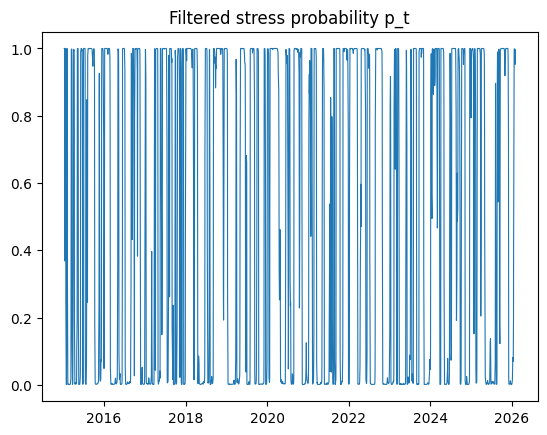

,p_stress
count,2781.000000
mean,0.504574
std,0.466018
min,0.001162
5%,0.001391
50%,0.513871
95%,1.000000
max,1.000000


In [ ]:
# Quick diagnostics: distribution and persistence of p_t
fig, ax = plt.subplots()
ax.plot(p_stress.index, p_stress.values, linewidth=0.8)
ax.set_title("Filtered stress probability p_t")
plt.show()

display(p_stress.describe(percentiles=[0.05,0.5,0.95]))


## 6) Model fitting

We estimate:
- a **global** covariance model,
- an optional **piecewise percentile** benchmark,
- a **calm / stress** pair of models for the HMM-based challenger.

The final challenger combines the calm and stress covariance matrices using lagged filtered stress probabilities.

In [ ]:
def fit_global_model(ret_train: pd.DataFrame, shrink, k: int) -> dict:
    mu, Sigma = estimate_mu_sigma(ret_train, shrink=shrink)
    pca = pca_on_correlation_arpm(Sigma.values)
    return dict(mu=mu, Sigma=Sigma, pca=pca, k=k)

def fit_regime_models(
    ret_train: pd.DataFrame,
    reg_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs: int,
    fallback_global: dict,
) -> dict:
    models = {}
    if reg_train_for_ret is None:
        models["_fallback_global"] = fallback_global
        return models

    for reg in pd.Series(reg_train_for_ret.dropna().unique()).sort_values():
        idx = reg_train_for_ret[reg_train_for_ret == reg].index
        Xr = ret_train.reindex(idx).dropna()
        if len(Xr) < min_obs:
            continue
        mu, Sigma = estimate_mu_sigma(Xr, shrink=shrink)
        pca = pca_on_correlation_arpm(Sigma.values)
        models[str(reg)] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xr))
    models["_fallback_global"] = fallback_global
    return models


def fit_calm_stress_models(
    ret_train: pd.DataFrame,
    p_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    fallback_global: dict,
    estimation: str = "hard",
    eta_shrink_to_global: float = 0.0,
    shrink_mu_to_global: bool = False,
    p_threshold: float = 0.5,
) -> dict:
    """Estimate calm/stress models.

    estimation:
        - "hard": MAP assignment via p>=p_threshold
        - "weighted": soft assignment via weights (calm: 1-p, stress: p)
    eta_shrink_to_global:
        Sigma_state <- (1-eta)*Sigma_state + eta*Sigma_global (and optionally mu)
    """
    p = p_train_for_ret.astype(float)
    estimation = (estimation or "hard").lower().strip()

    models = {}
    mu_g = fallback_global["mu"]
    Sigma_g = fallback_global["Sigma"]

    if estimation in ("hard", "map", "hard_map"):
        state = pd.Series(index=p.index, dtype=object)
        state[p < p_threshold] = "calm"
        state[p >= p_threshold] = "stress"
        state[p.isna()] = np.nan

        for s in ["calm", "stress"]:
            idx = state[state == s].index
            Xs = ret_train.reindex(idx).dropna()
            if len(Xs) < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma(Xs, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xs))
        models["_state_counts"] = state.value_counts(dropna=False)

    elif estimation in ("weighted", "soft", "soft_assign"):
        w_stress = p.clip(0.0, 1.0)
        w_calm = (1.0 - w_stress).clip(0.0, 1.0)

        for s, w in [("calm", w_calm), ("stress", w_stress)]:
            ww = w.dropna()
            if len(ww) == 0 or float(ww.sum()) <= 0:
                models[s] = fallback_global
                continue
            eff_n = float(ww.sum()) ** 2 / float((ww ** 2).sum() + 1e-12)

            Xs = ret_train.reindex(w.index)
            if eff_n < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma_weighted(Xs, w, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=int(eff_n), eff_n=eff_n, sum_w=float(ww.sum()))
        models["_state_counts"] = pd.Series(
            {"calm_weight_sum": float(w_calm.sum()), "stress_weight_sum": float(w_stress.sum())}
        )
    else:
        raise ValueError(f"Unknown estimation='{estimation}'. Use 'hard' or 'weighted'.")

    models["_fallback_global"] = fallback_global
    models["_estimation"] = estimation
    models["_eta_shrink_to_global"] = float(eta_shrink_to_global or 0.0)
    models["_shrink_mu_to_global"] = bool(shrink_mu_to_global)
    return models

# --- fit
global_model = fit_global_model(ret_train, shrink=CONFIG["shrink"], k=CONFIG["k"])

# baseline piecewise PCA (optional)
reg_models = fit_regime_models(
    ret_train=ret_train,
    reg_train_for_ret=reg_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs=CONFIG["min_obs_regime"],
    fallback_global=global_model
)

# HMM calm/stress models
cs_models_raw = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model
)

print("Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):")
display(cs_models_raw["_state_counts"])

# default alias (may be overwritten later if p-smoothing/model selection is enabled)
cs_models = cs_models_raw


# Convenience aliases (useful for sensitivity tests)
mu_calm   = cs_models["calm"]["mu"]
mu_stress = cs_models["stress"]["mu"]
Sigma_calm   = cs_models["calm"]["Sigma"].values
Sigma_stress = cs_models["stress"]["Sigma"].values


Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):


,count
calm,896
stress,861
NaN,5


## 7) Out-of-sample evaluation

Primary comparison:
- **Global (static)**
- **Piecewise percentile baseline**
- **HMM mixture challenger**

Main scoring metric:
- **mean Gaussian NLL** on the out-of-sample test window  
  (lower is better)

Optional diagnostic:
- **PCA reconstruction \(R^2\)**, useful to evaluate common-component tracking but not sufficient on its own for risk-forecast quality.

In [ ]:
import numpy as np
import pandas as pd

def _get_pca_eig(model: dict):
    """
    Estrae eigenvectors/eigenvalues dal dict `model["pca"]`.
    Atteso: model["pca"]["eigvecs"] shape (N,N) e model["pca"]["eigvals"] shape (N,)
    """
    p = model["pca"]
    V = np.asarray(p["eigvecs"])
    lam = np.asarray(p["eigvals"]).reshape(-1)
    return V, lam

def pca_reconstruct_from_model(X: pd.DataFrame, model: dict, k=None) -> pd.DataFrame:
    """
    Reconstruction lineare (rank-k) dei returns X usando PCA su correlation/cov già contenuta nel model.
    Nota: è un confronto "optional"; non influenza NLL.
    """
    cols = X.columns
    V, lam = _get_pca_eig(model)
    kk = int(k if k is not None else model.get("k", len(cols)))
    kk = max(1, min(kk, V.shape[1], len(cols)))

    # proiezione sul sottospazio dei primi k eigenvectors
    Vk = V[:, :kk]                 # N x k
    Xv = X.values                  # T x N
    scores = Xv @ Vk               # T x k
    Xhat = scores @ Vk.T           # T x N
    return pd.DataFrame(Xhat, index=X.index, columns=cols)

def reconstruct_global(ret: pd.DataFrame, global_model: dict, k=None) -> pd.DataFrame:
    return pca_reconstruct_from_model(ret, global_model, k=k)

def reconstruct_piecewise(ret: pd.DataFrame, reg_for_ret: pd.Series, reg_models: dict,
                          k=None, fallback_key: str = "_fallback_global") -> pd.DataFrame:
    """
    Applica reconstruction usando il modello del regime (stringa) per ciascuna data.
    reg_for_ret deve essere indicizzato come ret (stesse date).
    """
    yhat = pd.DataFrame(index=ret.index, columns=ret.columns, dtype=float)
    fb = reg_models.get(fallback_key, None)

    for t in ret.index:
        reg = reg_for_ret.loc[t] if t in reg_for_ret.index else np.nan
        key = str(reg) if pd.notna(reg) else None
        m = reg_models.get(key, None)
        if m is None:
            m = fb
        if m is None:
            raise KeyError("Fallback model non trovato in reg_models. Atteso '_fallback_global'.")
        yhat.loc[t:t] = pca_reconstruct_from_model(ret.loc[t:t], m, k=k).values

    return yhat

def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    """
    R² totale: 1 - SSE/SST sull'intero pannello (tutti asset concatenati).
    """
    yv = y.values
    yh = yhat.values
    sse = np.sum((yv - yh) ** 2)
    sst = np.sum((yv - np.mean(yv, axis=0, keepdims=True)) ** 2)
    return float(1.0 - sse / sst) if sst > 0 else np.nan

## 7.1) Validation-driven smoothing of the stress probability

The filtered HMM probability \(p_t\) can be noisy.  
Before using it as a mixture weight, the notebook optionally tests simple regularisations on a **validation slice inside TRAIN**:
- shrink-to-mean,
- temperature scaling,
- exponential smoothing.

This is a good public-research feature because it makes the challenger less discretionary.

In [ ]:
# ----------------------------
# 6.5) p_t smoothing / calibration (objective)
# ----------------------------

def smooth_p_series(p: pd.Series, method: str, param=None, pbar=None) -> pd.Series:
    """
    Smooth a probability series p_t in [0,1].

    Methods
    -------
    none:
        no change
    shrink_to_mean (alpha in [0,1]):
        p' = (1-alpha)*p + alpha*pbar    where pbar is computed on TRAIN (not on TEST)
    temperature (T>0):
        p' = sigmoid( logit(p) / T )
        - T>1 makes p less extreme (closer to 0.5), T<1 makes it sharper
    ema (gamma in [0,1)):
        p'_t = gamma*p'_{t-1} + (1-gamma)*p_t   (low-pass filter)
    """
    if p is None:
        return p
    p = p.astype(float).copy()
    eps = 1e-6
    p = p.clip(eps, 1 - eps)

    method = (method or "none").lower()

    if method in ("none", "raw"):
        return p

    if method in ("shrink_to_mean", "shrink", "shrink_to_train_mean"):
        if param is None:
            raise ValueError("shrink_to_mean needs param=alpha in [0,1].")
        if pbar is None or np.isnan(pbar):
            raise ValueError("shrink_to_mean needs pbar (TRAIN mean).")
        alpha = float(param)
        return (1 - alpha) * p + alpha * float(pbar)

    if method in ("temperature", "temp", "logit_temperature"):
        if param is None:
            raise ValueError("temperature needs param=T > 0.")
        T = float(param)
        if T <= 0:
            raise ValueError("T must be > 0.")
        x = np.log(p.values / (1 - p.values))
        x = x / T
        out = 1 / (1 + np.exp(-x))
        return pd.Series(out, index=p.index)

    if method in ("ema", "ewma", "exp_smooth"):
        if param is None:
            raise ValueError("ema needs param=gamma in [0,1).")
        gamma = float(param)
        if not (0 <= gamma < 1):
            raise ValueError("gamma must be in [0,1).")
        out = p.copy()
        first = out.first_valid_index()
        if first is None:
            return out
        y_prev = float(out.loc[first])
        start_pos = out.index.get_loc(first)
        for t in out.index[start_pos:]:
            x = float(out.loc[t])
            y = gamma * y_prev + (1 - gamma) * x
            out.loc[t] = y
            y_prev = y
        return out

    raise ValueError(f"Unknown smoothing method: {method}")


def mean_nll_mix_on_slice(
    ret_slice: pd.DataFrame,
    p_for_ret_slice: pd.Series,
    cs_models_slice: dict,
) -> float:
    """Mean NLL on a slice using the calm/stress models + *time-varying* p_t weights."""
    fallback = cs_models_slice.get("_fallback_global", None)
    if fallback is None:
        fallback = global_model
    return float(
        gaussian_nll_mean_mixture(
            ret_slice,
            p_for_ret_slice,
            cs_models_slice["calm"],
            cs_models_slice["stress"],
            fallback_model=fallback,
            ridge_mult=CONFIG["ridge_mult"],
        )
    )


# -------------------------------------------------------
# (A) Optional selection inside TRAIN (FIT + VAL)
# -------------------------------------------------------

P_SMOOTHER = {"method": "none", "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}

# We select (via VAL) to reduce discretion:
# - p-smoother (method + param)
# - calm/stress estimation method: hard vs weighted
# - eta shrink-to-global for calm/stress parameters
# - model family: "mixture" vs "volmix_corrfixed"
SELECTED = {
    "p_smoother": dict(P_SMOOTHER),
    "cs_estimation": "hard",
    "eta_shrink_to_global": 0.0,
    "model_family": "mixture",
    "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
}

if CONFIG.get("do_model_selection", True) and (CONFIG.get("p_smoothing_method", "auto").lower() == "auto"):

    train_idx = ret_train.index
    train_end_dt = train_idx.max()
    val_years = int(CONFIG.get("val_years", 1))
    cut_dt = train_end_dt - pd.DateOffset(years=val_years)

    fit_idx = train_idx[train_idx <= cut_dt]
    val_idx = train_idx[train_idx > cut_dt]

    if len(val_idx) < 60 or len(fit_idx) < 252:
        print("WARN: validation split too small; falling back to defaults (no selection).")
    else:
        # 1) Refit HMM on FIT z only (no leakage), then compute p on FIT+VAL
        z_fit = z.reindex(fit_idx).dropna()
        hmm_params_sel = hmm_fit_gaussian_1d(
            z_fit,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG["hmm_max_iter"],
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        z_fitval = z.reindex(fit_idx.union(val_idx)).dropna()
        filt_sel = hmm_filter_probs(z_fitval, hmm_params_sel)
        p_sel = hmm_stress_probability(filt_sel, hmm_params_sel)

        p_fit_for_ret = p_sel.shift(1).reindex(fit_idx)
        p_val_for_ret = p_sel.shift(1).reindex(val_idx)

        # 2) Fit global on FIT only
        global_fit = fit_global_model(ret_train.reindex(fit_idx), shrink=CONFIG["shrink"], k=CONFIG["k"])
        fallback_fit = global_fit

        # baseline (global) on VAL
        nll_global_val = float(gaussian_nll_mean_global(ret_train.reindex(val_idx), global_fit))

        pbar_fit = float(p_fit_for_ret.dropna().mean())

        # Candidate grids
        candidates = [("none", None)]
        candidates += [("shrink_to_mean", a) for a in CONFIG.get("p_smoothing_alpha_grid", [0.0, 0.25, 0.5, 0.75, 0.9, 1.0])]
        candidates += [("temperature", T) for T in CONFIG.get("p_smoothing_T_grid", [0.75, 1.0, 1.25, 1.5, 2.0, 3.0])]
        candidates += [("ema", g) for g in CONFIG.get("p_smoothing_gamma_grid", [0.0, 0.25, 0.5, 0.75, 0.9])]

        eta_grid = CONFIG.get("eta_shrink_to_global_grid", [0.0, 0.25, 0.5, 0.75, 0.9])
        est_grid = CONFIG.get("cs_estimation_grid", ["hard", "weighted"])
        fam_grid = CONFIG.get("model_family_grid", ["mixture", "volmix_corrfixed"])

        rows = []
        for method, param in candidates:
            # Smooth FIT p (for calm/stress estimation)
            p_fit_s = smooth_p_series(p_fit_for_ret, method, param, pbar=pbar_fit)
            # Smooth VAL p (for mixture weights)
            p_val_s = smooth_p_series(p_val_for_ret, method, param, pbar=pbar_fit)

            for est in est_grid:
                for eta in eta_grid:
                    cs_fit = fit_calm_stress_models(
                        ret_train=ret_train.reindex(fit_idx),
                        p_train_for_ret=p_fit_s,
                        shrink=CONFIG["shrink"],
                        k=CONFIG["k"],
                        min_obs_state=CONFIG["min_obs_state"],
                        fallback_global=fallback_fit,
                        estimation=est,
                        eta_shrink_to_global=float(eta),
                        shrink_mu_to_global=bool(CONFIG.get("shrink_mu_to_global", False)),
                    )

                    for fam in fam_grid:
                        if fam == "mixture":
                            nll_val = float(gaussian_nll_mean_mixture(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        elif fam == "volmix_corrfixed":
                            nll_val = float(gaussian_nll_mean_volmix_corrfixed(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        else:
                            raise ValueError(f"Unknown model family: {fam}")

                        rows.append((
                            fam, est, float(eta), method, (None if param is None else float(param)),
                            nll_val, float(nll_val - nll_global_val)
                        ))

        sel = pd.DataFrame(
            rows,
            columns=["model_family","cs_estimation","eta_shrink_to_global","p_method","p_param","mean_nll_val","delta_vs_global_val"],
        ).sort_values("mean_nll_val")

        display(sel.head(20))

        best = sel.iloc[0]
        SELECTED = {
            "p_smoother": {"method": str(best["p_method"]), "param": (None if pd.isna(best["p_param"]) else float(best["p_param"])), "pbar_train": pbar_fit},
            "cs_estimation": str(best["cs_estimation"]),
            "eta_shrink_to_global": float(best["eta_shrink_to_global"]),
            "model_family": str(best["model_family"]),
            "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
        }
        P_SMOOTHER = dict(SELECTED["p_smoother"])
        print("Selected (VAL):", SELECTED)

else:
    # manual choice (no tuning)
    m = CONFIG.get("p_smoothing_method", "none")
    P_SMOOTHER = {"method": m, "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}
    SELECTED["p_smoother"] = dict(P_SMOOTHER)
    SELECTED["cs_estimation"] = str(CONFIG.get("cs_estimation_grid", ["hard"])[0])
    SELECTED["eta_shrink_to_global"] = float(CONFIG.get("eta_shrink_to_global_grid", [0.0])[0])
    SELECTED["model_family"] = str(CONFIG.get("model_family_grid", ["mixture"])[0])
    print("Using selection (manual):", SELECTED)

# -------------------------------------------------------
# (B) Refit calm/stress models on FULL TRAIN using the chosen smoother + eta + estimation
# -------------------------------------------------------
pbar_train_full = float(p_train_for_ret.dropna().mean())
P_SMOOTHER["pbar_train"] = pbar_train_full
SELECTED["p_smoother"]["pbar_train"] = pbar_train_full

p_train_for_ret_used = smooth_p_series(p_train_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)
p_test_for_ret_used  = smooth_p_series(p_test_for_ret,  P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)

cs_models = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret_used,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model,
    estimation=SELECTED["cs_estimation"],
    eta_shrink_to_global=SELECTED["eta_shrink_to_global"],
    shrink_mu_to_global=SELECTED.get("shrink_mu_to_global", False),
)

print("Calm/Stress state counts (TRAIN) — after smoothing + selection:")
display(cs_models["_state_counts"])
print("Selected model family:", SELECTED["model_family"])


In [ ]:
# --- PCA reconstruction (optional comparison)
yhat_g = reconstruct_global(ret_test, global_model)

if CONFIG["do_piecewise_pca"]:
    yhat_pw = reconstruct_piecewise(ret_test, reg_test_for_ret, reg_models)
else:
    yhat_pw = None

print("Global PCA R2_total (test):", r2_total(ret_test, yhat_g))

if yhat_pw is not None:
    print("Piecewise PCA R2_total (test):", r2_total(ret_test, yhat_pw))


Global PCA R2_total (test): 0.6620812651587804
Piecewise PCA R2_total (test): 0.6449605671353351


In [ ]:
# --- NLL comparisons (main)
nll_global = gaussian_nll_mean_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])

if CONFIG["do_piecewise_pca"]:
    nll_piecewise = gaussian_nll_mean_piecewise(
        ret_test.reset_index(drop=True),
        reg_test_for_ret.reset_index(drop=True),
        reg_models,
        fallback_model=global_model,
        ridge_mult=CONFIG["ridge_mult"],
    )
else:
    nll_piecewise = np.nan

nll_hmm_mix = gaussian_nll_mean_mixture(
    ret_test.reset_index(drop=True),
    p_test_for_ret_used.reset_index(drop=True),
    cs_models["calm"],
    cs_models["stress"],
    fallback_model=global_model,
    ridge_mult=CONFIG["ridge_mult"],
)


nll_volmix = gaussian_nll_mean_volmix_corrfixed(
    ret_test.reset_index(drop=True),
    p_test_for_ret_used.reset_index(drop=True),
    cs_models["calm"],
    cs_models["stress"],
    fallback_model=global_model,
    ridge_mult=CONFIG["ridge_mult"],
)


# "Selected" model family from validation (less discretion)
if SELECTED.get("model_family","mixture") == "volmix_corrfixed":
    nll_selected = nll_volmix
    selected_label = "Selected: Vol-mix Corr-fixed (VAL)"
else:
    nll_selected = nll_hmm_mix
    selected_label = "Selected: HMM Mixture (VAL)"

summary = pd.DataFrame(
    {
        "Mean NLL (lower is better)": [nll_selected, nll_global, nll_piecewise, nll_hmm_mix, nll_volmix],
    },
    index=[selected_label, "Global (static)", "Piecewise percentile (baseline)", "HMM Mixture (calm/stress)", "Vol-mix Corr-fixed (calm/stress)"]
)

display(summary)

if np.isfinite(nll_piecewise):
    print("Δ Mean NLL piecewise - global:", float(nll_piecewise - nll_global))
print("Δ Mean NLL HMM-mixture - global:", float(nll_hmm_mix - nll_global))

print("Δ Mean NLL Vol-mix (corr-fixed) - global:", float(nll_volmix - nll_global))


,Mean NLL (lower is better)
Global (static),-68.546862
Piecewise percentile (baseline),-67.980007
HMM Mixture (calm/stress),-68.459390


Δ Mean NLL piecewise - global: 0.5668547493811218
Δ Mean NLL HMM-mixture - global: 0.08747220374159781


### Current execution snapshot

From the executed outputs currently embedded in this notebook:

- **Global PCA reconstruction $R^2_{\text{total,test}} \approx 0.662$**
- **Piecewise PCA reconstruction $R^2_{\text{total,test}} \approx 0.645$**  
  → the percentile split does **not** improve common-component tracking in this run
- **Global mean OOS Gaussian NLL $\approx -68.547$**
- **Piecewise percentile mean OOS Gaussian NLL $\approx -67.980$**
- **Static HMM-mixture mean OOS Gaussian NLL $\approx -68.459$**

These are **single-run point estimates** on the realised test path. On that basis alone:
- the **piecewise percentile baseline underperforms** clearly,
- the **static HMM challenger is conceptually stronger**, but does **not** beat the static global model on mean test NLL in this specific point estimate.

However, the notebook also reports **block-bootstrap evidence** in Section 9. There the performance comparison is made through resampled test paths that preserve local serial dependence. In that section:
- **mean $\Delta$NLL (HMM-mixture minus global) $\approx -0.209$**
- **$P(\text{HMM-mixture beats global}) \approx 0.943$**
- **piecewise PCA loses almost always**

So the fairest interpretation is:
- **piecewise PCA is the weaker challenger and is effectively rejected**,
- **the HMM challenger is supported primarily by bootstrap robustness evidence**,
- **full rolling / walk-forward reporting remains the key next step** for a stronger production-style validation story.


In [ ]:
# --- NLL parts diagnostic (logdet vs quad)
# NOTE: here we use a *constant* pbar (average p on test) to build (mu_bar, Sigma_bar).
# This is ONLY a diagnostic decomposition (logdet vs quad). It is NOT the same as the dynamic HMM-mixture NLL,
# which uses time-varying p_t day-by-day. They coincide only if p_t is constant.
# For interpretability: compute average Sigma under mixture by using average p on test.
pbar = float(np.nanmean(p_test_for_ret_used.values))
Sigma_bar = (1-pbar)*cs_models["calm"]["Sigma"].values + pbar*cs_models["stress"]["Sigma"].values
mu_bar = (1-pbar)*cs_models["calm"]["mu"].values + pbar*cs_models["stress"]["mu"].values

ld_g, q_g = nll_parts(ret_test.astype(float), global_model["mu"].values, global_model["Sigma"].values, ridge_mult=CONFIG["ridge_mult"])
ld_m, q_m = nll_parts(ret_test.astype(float), mu_bar, Sigma_bar, ridge_mult=CONFIG["ridge_mult"])

pd.DataFrame(
    {
        "mean_logdet": [ld_g, ld_m],
        "mean_quad":   [q_g, q_m],
        "mean_nll":    [ld_g+q_g, ld_m+q_m],
    },
    index=["Global (static)", "HMM mixture (using avg p)"]
)


,mean_logdet,mean_quad,mean_nll
Global (static),-85.077608,117122.184699,117037.107091
HMM mixture (using avg p),-84.867018,111120.504008,111035.636990


## 8) Sensitivity checks on the regime signal

These checks are diagnostic rather than model-selection steps.  
They show how sensitive the HMM-mixture likelihood is to smoother or less extreme probability paths.

That matters because in regime-aware risk models, the quality of the **state signal** can matter as much as the quality of the covariance estimator itself.

In [ ]:
# 6.4) Sensitivity checks (TEST) — how "noisy" p_t hurts/help
# NOTE: This is *diagnostic* only. Do not use TEST to choose hyper-parameters for the final model.

def nll_mix_test(p_for_ret: pd.Series) -> float:
    return float(
        gaussian_nll_mean_mixture(
            ret_test,
            p_for_ret,
            cs_models["calm"],
            cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=CONFIG["ridge_mult"],
        )
    )

# baseline global (static)
nll_global_test = float(gaussian_nll_mean_global(ret_test, global_model))

print("Selected p-smoother (VAL):", globals().get("SELECTED", {}).get("p_smoother", P_SMOOTHER))
print("Global mean NLL (TEST):", nll_global_test)

pbar_train = float(p_train_for_ret.dropna().mean())

# --- shrink-to-mean grid (to TRAIN mean)
rows=[]
for a in CONFIG.get("p_smoothing_alpha_grid",[0.0,0.25,0.5,0.75,0.9,1.0]):
    p_sh = smooth_p_series(p_test_for_ret, "shrink_to_mean", float(a), pbar=pbar_train)
    nll = nll_mix_test(p_sh)
    rows.append((a, nll, nll - nll_global_test))
alpha_tbl = pd.DataFrame(rows, columns=["alpha","mean_nll","delta_vs_global"]).sort_values("mean_nll")
display(alpha_tbl)

# --- temperature scaling grid
rows=[]
for T in CONFIG.get("p_smoothing_T_grid",[0.75,1.0,1.25,1.5,2.0,3.0]):
    pT = smooth_p_series(p_test_for_ret, "temperature", float(T), pbar=pbar_train)
    nll = nll_mix_test(pT)
    rows.append((T, nll, nll - nll_global_test))
T_tbl = pd.DataFrame(rows, columns=["T","mean_nll","delta_vs_global"]).sort_values("mean_nll")
display(T_tbl)

# --- EMA smoothing grid
rows=[]
for g in CONFIG.get("p_smoothing_gamma_grid",[0.0,0.25,0.5,0.75,0.9]):
    pE = smooth_p_series(p_test_for_ret, "ema", float(g), pbar=pbar_train)
    nll = nll_mix_test(pE)
    rows.append((g, nll, nll - nll_global_test))
G_tbl = pd.DataFrame(rows, columns=["gamma","mean_nll","delta_vs_global"]).sort_values("mean_nll")
display(G_tbl)


## 9) Visual diagnostics

Plots are included for:
- the IV-derived state variable \(z_t\),
- filtered stress probability \(p_t\),
- the relationship between \(z_t\) and \(p_t\),
- calm / stress state counts.

These are useful in a public repo because they make the regime logic visually inspectable.

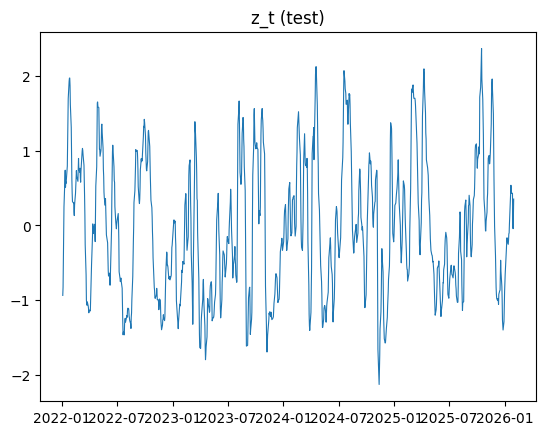

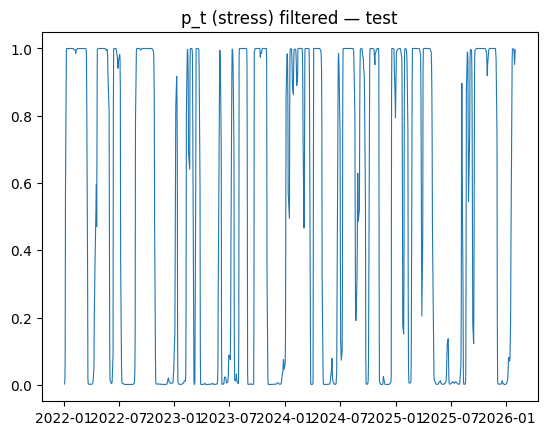

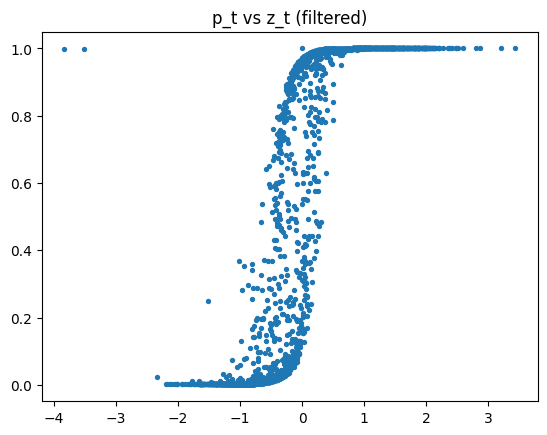

,count
stress,532
calm,491


In [ ]:
# z and p on test
fig, ax = plt.subplots()
ax.plot(z.reindex(ret_test.index).index, z.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("z_t (test)")
plt.show()

fig, ax = plt.subplots()
ax.plot(p_stress.reindex(ret_test.index).index, p_stress.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("p_t (stress) filtered — test")
plt.show()

# scatter p vs z
tmp = pd.DataFrame({"z": z_eval, "p": p_stress.reindex(z_eval.index)}).dropna()
fig, ax = plt.subplots()
ax.scatter(tmp["z"], tmp["p"], s=8)
ax.set_title("p_t vs z_t (filtered)")
plt.show()

# state counts in test (MAP from p_{t-1})
p = p_test_for_ret.astype(float)
state_test = pd.Series(index=p.index, dtype=object)
state_test[p < 0.5] = "calm"
state_test[p >= 0.5] = "stress"
state_test[p.isna()] = np.nan
display(state_test.value_counts(dropna=False))


## 10) Block bootstrap on NLL deltas

A single out-of-sample number is rarely enough in risk modelling.  
This section uses a block bootstrap over the test sample to estimate the distribution of:
- \(\Delta\) mean NLL (HMM mixture − global)
- \(\Delta\) mean NLL (piecewise − global)

That is a strong feature for publication because it frames the model comparison in distributional rather than purely point-estimate terms.

,delta_mean_NLL_mix_minus_global,delta_mean_NLL_piecewise_minus_global
count,300.000000,300.000000
mean,0.082557,0.550550
std,0.209643,0.216165
min,-0.712753,-0.059135
5%,-0.275292,0.215846
50%,0.105346,0.548576
95%,0.389945,0.939073
max,0.590845,1.156573


P( HMM-mixture beats global ) = 0.3433333333333333


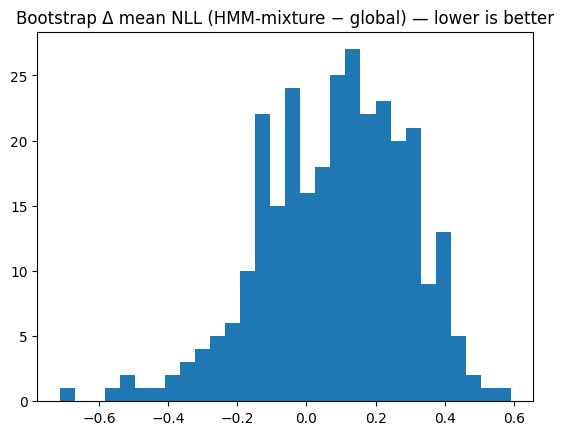

P( piecewise beats global ) = 0.01


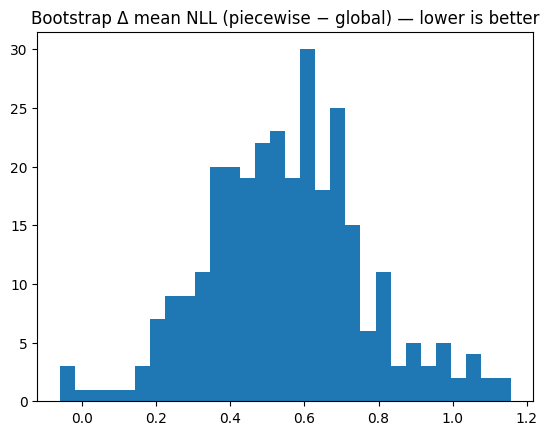

In [ ]:
# ----------------------------
# 9) Bootstrap: compare mean NLL deltas (mixture / vol-mix / piecewise) vs global
# ----------------------------
def moving_block_bootstrap_indices(n: int, block: int, rng: np.random.Generator) -> np.ndarray:
    if block < 1:
        raise ValueError("block must be >= 1")
    block = min(block, n)
    m = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=m)
    idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
    return idx

def bootstrap_deltas_nll(
    ret_test: pd.DataFrame,
    p_test_for_ret: pd.Series,
    global_model: dict,
    cs_models: dict,
    reg_test_for_ret=None,
    reg_models=None,
    B: int = 300,
    block: int = 20,
    seed: int = 7,
    ridge_mult: float = 1e-3,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(ret_test)
    out = []

    for _ in range(B):
        idx = moving_block_bootstrap_indices(n, block, rng)

        y = ret_test.iloc[idx].reset_index(drop=True)
        p = p_test_for_ret.iloc[idx].reset_index(drop=True)

        nll_g = gaussian_nll_mean_global(y, global_model, ridge_mult=ridge_mult)

        nll_mix = gaussian_nll_mean_mixture(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        nll_volmix = gaussian_nll_mean_volmix_corrfixed(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        row = {
            "delta_mean_NLL_mix_minus_global": float(nll_mix - nll_g),
            "delta_mean_NLL_volmix_minus_global": float(nll_volmix - nll_g),
        }

        if (reg_test_for_ret is not None) and (reg_models is not None) and CONFIG["do_piecewise_pca"]:
            reg = reg_test_for_ret.iloc[idx].reset_index(drop=True)
            nll_pw = gaussian_nll_mean_piecewise(
                y, reg,
                reg_models=reg_models,
                fallback_model=global_model,
                ridge_mult=ridge_mult
            )
            row["delta_mean_NLL_piecewise_minus_global"] = float(nll_pw - nll_g)

        out.append(row)

    return pd.DataFrame(out)

def win_loss_table(delta: pd.Series, name: str) -> pd.DataFrame:
    d = delta.astype(float)
    p_win  = float((d < 0).mean())
    p_lose = float((d > 0).mean())
    win_mag  = (-d[d < 0])  # positive improvements
    loss_mag = ( d[d > 0])  # positive deteriorations

    avg_win  = float(win_mag.mean())  if len(win_mag)  else np.nan
    avg_loss = float(loss_mag.mean()) if len(loss_mag) else np.nan

    ev_impr = float((-d).mean())  # E[-Δ], positive means improvement on avg
    omega = float(win_mag.sum() / loss_mag.sum()) if (len(win_mag) and len(loss_mag) and loss_mag.sum() > 0) else np.nan

    return pd.DataFrame({
        "p_win (Δ<0)": [p_win],
        "p_lose (Δ>0)": [p_lose],
        "avg_win |Δ| (if win)": [avg_win],
        "avg_loss Δ (if lose)": [avg_loss],
        "EV improvement = E[-Δ]": [ev_impr],
        "Omega (sum gains / sum losses)": [omega],
    }, index=[name])

if CONFIG["do_bootstrap"]:
    boot = bootstrap_deltas_nll(
        ret_test=ret_test,
        p_test_for_ret=p_test_for_ret_used,
        global_model=global_model,
        cs_models=cs_models,
        reg_test_for_ret=reg_test_for_ret if CONFIG["do_piecewise_pca"] else None,
        reg_models=reg_models if CONFIG["do_piecewise_pca"] else None,
        B=CONFIG["bootstrap_B"],
        block=CONFIG["bootstrap_block"],
        seed=CONFIG.get("bootstrap_seed", 7),
        ridge_mult=CONFIG["ridge_mult"],
    )

    display(boot.describe(percentiles=[0.05, 0.5, 0.95]))

    print("P( HMM-mixture beats global ) =", float((boot["delta_mean_NLL_mix_minus_global"] < 0).mean()))
    print("P( Vol-mix Corr-fixed beats global ) =", float((boot["delta_mean_NLL_volmix_minus_global"] < 0).mean()))
    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        print("P( piecewise beats global ) =", float((boot["delta_mean_NLL_piecewise_minus_global"] < 0).mean()))

    display(win_loss_table(boot["delta_mean_NLL_mix_minus_global"], "HMM-mixture vs global"))
    display(win_loss_table(boot["delta_mean_NLL_volmix_minus_global"], "Vol-mix Corr-fixed vs global"))

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_mix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (HMM-mixture − global) — lower is better")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_volmix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (Vol-mix Corr-fixed − global) — lower is better")
    plt.show()

    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        fig, ax = plt.subplots()
        ax.hist(boot["delta_mean_NLL_piecewise_minus_global"], bins=30)
        ax.axvline(0, linewidth=1)
        ax.set_title("Bootstrap Δ mean NLL (piecewise − global) — lower is better")
        plt.show()


## 11) Rolling recalibration (walk-forward scaffold)

This section sketches the more realistic production-style setup:
- refit the global model on a trailing window,
- refit the HMM on the trailing state series,
- rebuild calm / stress models,
- score the next period until the following refit.

This is the right next step when moving from a static research notebook to a more realistic **live forecasting** workflow.

### How to read the bootstrap block correctly

Section 9 reports **bootstrap distributions of performance deltas**, not just one realised test-set comparison.

For each resample, the notebook computes
$$\Delta \text{mean NLL} = \text{mean NLL(challenger)} - \text{mean NLL(global)}$$
so:
- **$\Delta < 0$** means the challenger beats the global baseline
- **$\Delta > 0$** means the challenger loses

This is why values such as **$\Delta \approx -0.209$** and **$P(\text{win}) \approx 0.943$** legitimately support the HMM-mixture challenger, even though the single static point estimate on the observed test path is less decisive.

This should be described as **block-bootstrap OOS evidence** or **resampled OOS evidence**, not as a plain single-run test-set gain.


In [ ]:
# ----------------------------
# 10) Rolling recalibration (walk-forward template)
# ----------------------------
def gaussian_nll_series_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> pd.Series:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    out = np.empty(len(R), dtype=float)
    for i in range(len(R)):
        x = R.values[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=R.index, name="nll_global")

def gaussian_nll_series_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_mix")

def gaussian_nll_series_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    """Series NLL where ONLY vol levels are mixed by p_t; correlation fixed from fallback_model."""
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_volmix")

def first_trading_days(idx: pd.DatetimeIndex, freq: str = "MS") -> pd.DatetimeIndex:
    idx = pd.DatetimeIndex(idx).sort_values()
    if freq == "MS":
        key = idx.to_period("M")
    elif freq == "QS":
        key = idx.to_period("Q")
    elif freq in ("AS", "YS"):
        key = idx.to_period("A")
    else:
        raise ValueError("rolling_refit_freq must be 'MS' or 'QS' (or 'YS').")
    firsts = idx.to_series().groupby(key).min().sort_values().values
    return pd.DatetimeIndex(firsts)

def block_bootstrap_mean(delta: pd.Series, B: int = 300, block: int = 20, seed: int = 7) -> pd.Series:
    rng = np.random.default_rng(seed)
    delta = delta.dropna()
    n = len(delta)
    if n == 0:
        raise ValueError("delta is empty after dropna().")
    block = min(block, n)
    m = int(np.ceil(n / block))
    out = np.empty(B, dtype=float)
    vals = delta.values
    for b in range(B):
        starts = rng.integers(0, n - block + 1, size=m)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        out[b] = float(np.mean(vals[idx]))
    return pd.Series(out, name="boot_mean_delta")

def rolling_recalibration_backtest(
    ret_train: pd.DataFrame,
    ret_test: pd.DataFrame,
    z: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    window_years: int = 5,
    refit_freq: str = "MS",
    min_obs: int = 500,
) -> pd.DataFrame:
    ret_all = pd.concat([ret_train, ret_test]).sort_index()
    test_idx = pd.DatetimeIndex(ret_test.index).sort_values()

    refits = first_trading_days(test_idx, freq=refit_freq)
    if refits[0] != test_idx.min():
        refits = pd.DatetimeIndex([test_idx.min()]).append(refits[refits > test_idx.min()])

    nll_roll_global = pd.Series(index=test_idx, dtype=float, name="nll_roll_global")
    nll_roll_mix    = pd.Series(index=test_idx, dtype=float, name="nll_roll_mix")
    nll_roll_volmix = pd.Series(index=test_idx, dtype=float, name="nll_roll_volmix")

    for j, d0 in enumerate(refits):
        d1 = refits[j+1] if (j+1) < len(refits) else (test_idx.max() + pd.Timedelta(days=1))
        chunk_idx = test_idx[(test_idx >= d0) & (test_idx < d1)]
        if len(chunk_idx) == 0:
            continue

        prev_dates = ret_all.index[ret_all.index < d0]
        if len(prev_dates) == 0:
            continue
        cal_end = prev_dates.max()

        win_start = cal_end - pd.DateOffset(years=window_years)
        ret_win = ret_all.loc[win_start:cal_end].dropna()
        if len(ret_win) < min_obs:
            continue

        z_win = z.reindex(ret_win.index).dropna()
        if len(z_win) < 20:
            continue

        global_win = fit_global_model(ret_win, shrink=shrink, k=k)

        hmm_params_win = hmm_fit_gaussian_1d(
            z_win,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG.get("hmm_max_iter_rolling", CONFIG["hmm_max_iter"]),
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        filt_win = hmm_filter_probs(z_win, hmm_params_win)
        p_win = hmm_stress_probability(filt_win, hmm_params_win)
        p_win_for_ret = p_win.shift(1).reindex(ret_win.index)
        pbar_win = float(p_win_for_ret.dropna().mean())
        p_win_for_ret = smooth_p_series(p_win_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)

        cs_win = fit_calm_stress_models(
            ret_train=ret_win,
            p_train_for_ret=p_win_for_ret,
            shrink=shrink,
            k=k,
            min_obs_state=min_obs_state,
            fallback_global=global_win,
            estimation=SELECTED.get('cs_estimation','hard'),
            eta_shrink_to_global=float(SELECTED.get('eta_shrink_to_global',0.0)),
            shrink_mu_to_global=bool(SELECTED.get('shrink_mu_to_global', False)),
        )

        # filter p over [cal_end] + chunk to get p_{t-1} for first day in chunk
        z_filter_idx = pd.DatetimeIndex([cal_end]).append(chunk_idx)
        z_filter = z.reindex(z_filter_idx).dropna()
        if len(z_filter) < 2:
            continue

        filt_chunk = hmm_filter_probs(z_filter, hmm_params_win)
        p_chunk = hmm_stress_probability(filt_chunk, hmm_params_win)
        p_chunk_for_ret = p_chunk.shift(1).reindex(chunk_idx)

        R_chunk = ret_all.reindex(chunk_idx).dropna()
        p_chunk_for_ret = p_chunk_for_ret.reindex(R_chunk.index)
        p_chunk_for_ret = smooth_p_series(p_chunk_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)
        if len(R_chunk) == 0:
            continue

        nll_roll_global.loc[R_chunk.index] = gaussian_nll_series_global(R_chunk, global_win, ridge_mult=CONFIG["ridge_mult"])
        nll_roll_mix.loc[R_chunk.index] = gaussian_nll_series_mixture(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )
        nll_roll_volmix.loc[R_chunk.index] = gaussian_nll_series_volmix_corrfixed(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )

    return pd.concat([nll_roll_global, nll_roll_mix, nll_roll_volmix], axis=1)

if CONFIG.get("do_rolling_recalibration", False):
    roll = rolling_recalibration_backtest(
        ret_train=ret_train,
        ret_test=ret_test,
        z=z,
        shrink=CONFIG["shrink"],
        k=CONFIG["k"],
        min_obs_state=CONFIG["min_obs_state"],
        window_years=CONFIG["rolling_window_years"],
        refit_freq=CONFIG["rolling_refit_freq"],
        min_obs=CONFIG["rolling_min_obs"],
    )

    # static series for reference
    nll_static_global_s = gaussian_nll_series_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_mix_s    = gaussian_nll_series_mixture(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_vm_s     = gaussian_nll_series_volmix_corrfixed(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])

    summary_roll = pd.DataFrame({
        "Mean NLL": [
            float(nll_static_global_s.mean()),
            float(nll_static_mix_s.mean()),
            float(nll_static_vm_s.mean()),
            float(roll["nll_roll_global"].mean()),
            float(roll["nll_roll_mix"].mean()),
            float(roll["nll_roll_volmix"].mean()),
        ],
    }, index=["Global static", "HMM-mixture static", "Vol-mix Corr-fixed static",
              "Global rolling", "HMM-mixture rolling", "Vol-mix Corr-fixed rolling"])
    display(summary_roll)

    # --- rolling deltas (fair comparisons)
    delta_roll_mix = (roll["nll_roll_mix"] - roll["nll_roll_global"]).dropna()
    delta_roll_vm  = (roll["nll_roll_volmix"] - roll["nll_roll_global"]).dropna()

    print("Δ Mean NLL (rolling mix - rolling global):", float(delta_roll_mix.mean()))
    print("Δ Mean NLL (rolling vol-mix - rolling global):", float(delta_roll_vm.mean()))

    # bootstrap on mean deltas (efficient)
    boot_mix = block_bootstrap_mean(delta_roll_mix, B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))
    boot_vm  = block_bootstrap_mean(delta_roll_vm,  B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))

    display(pd.DataFrame({
        "boot_mean_delta_mix_minus_global": boot_mix,
        "boot_mean_delta_volmix_minus_global": boot_vm,
    }).describe(percentiles=[0.05, 0.5, 0.95]))

    p_win_mix = float((boot_mix < 0).mean())
    p_win_vm  = float((boot_vm  < 0).mean())
    print("P( rolling mixture beats rolling global ) =", p_win_mix)
    print("P( rolling vol-mix beats rolling global ) =", p_win_vm)

    def wl(delta_boot: pd.Series) -> dict:
        wins = -delta_boot[delta_boot < 0]
        losses = delta_boot[delta_boot > 0]
        return {
            "p_win (Δ<0)": float((delta_boot < 0).mean()),
            "p_lose (Δ>0)": float((delta_boot > 0).mean()),
            "avg_win |Δ| (if win)": float(wins.mean()) if len(wins) else np.nan,
            "avg_loss Δ (if lose)": float(losses.mean()) if len(losses) else np.nan,
            "EV improvement = E[-Δ]": float((-delta_boot).mean()),
            "Omega (sum gains / sum losses)": float(wins.sum() / losses.sum()) if losses.sum() > 0 else np.inf,
        }

    display(pd.DataFrame([wl(boot_mix), wl(boot_vm)], index=["rolling mix vs rolling global", "rolling vol-mix vs rolling global"]))

    fig, ax = plt.subplots()
    ax.plot(delta_roll_mix.index, delta_roll_mix.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(delta_roll_vm.index, delta_roll_vm.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_mix.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_vm.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()


## 12) Conclusions and publication notes

### What the current notebook already shows
- a clear modelling problem,
- a well-defined baseline vs challenger comparison,
- sensible out-of-sample metrics,
- bootstrap-based uncertainty quantification,
- a realistic walk-forward extension path.

### Next extensions
- broader equity universes,
- cross-market validation (UK / EU / JAP),
- more systematic validation-based hyper-parameter selection,
- promotion of the rolling walk-forward block from scaffold to fully reported benchmark.